Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3796 - loss: 0.7371 - val_accuracy: 0.5467 - val_loss: 0.6893
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5298 - loss: 0.6913 - val_accuracy: 0.6000 - val_loss: 0.6608
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6323 - loss: 0.6572 - val_accuracy: 0.6533 - val_loss: 0.6367
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6933 - loss: 0.6350 - val_accuracy: 0.7067 - val_loss: 0.6140
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7328 - loss: 0.6085 - val_accuracy: 0.7200 - val_loss: 0.5915
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7627 - loss: 0.5728 - val_accuracy: 0.7333 - val_loss: 0.5695
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8097 - loss: 0.5464 - val_accuracy: 0.7467 - val_loss: 0.5473
Epoch 8/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8556 - loss: 0.5156 - val_accuracy: 0.7600 - val_loss: 0.5255
E

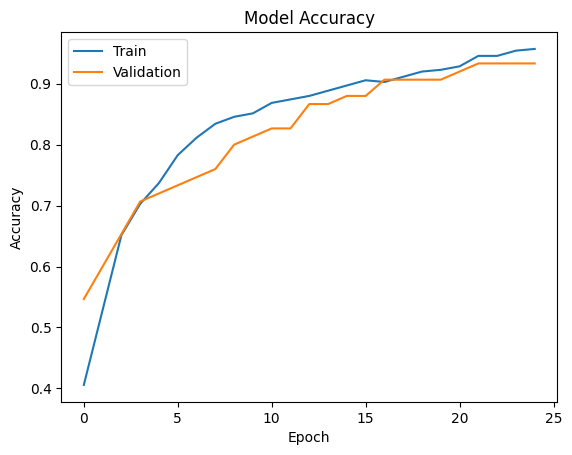

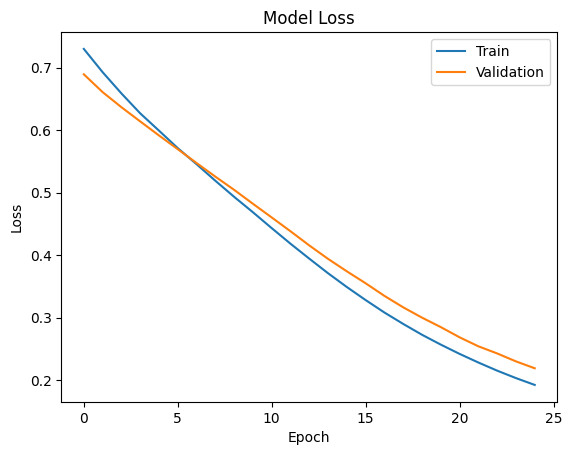

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# -----------------------------
# Generate synthetic dataset
# -----------------------------
n = 500

workouts = np.random.randint(2,7,n)
sleep = np.random.uniform(5,9,n)
protein = np.random.uniform(80,220,n)
experience = np.random.uniform(1,48,n)
consistency = np.random.randint(0,2,n)

X = np.column_stack((workouts, sleep, protein, experience, consistency))

# Nonlinear relationship
y = ((0.3*workouts +
      0.25*sleep +
      0.002*protein +
      0.02*experience +
      0.5*consistency) > 4).astype(int)

# -----------------------------
# Normalize features
# -----------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -----------------------------
# Train/Dev/Test Split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# -----------------------------
# Build MLP Model
# -----------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(5,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=25,
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_acc)

predictions = (model.predict(X_test) > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# -----------------------------
# Plot Curves
# -----------------------------
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()